# Task 3 — Event Impact Modeling

Modeling how events (policies, product launches, infrastructure investments)
affect financial inclusion indicators, using the `impact_links` records from
the Task 1/2 enriched dataset.

Covers: understanding the impact data, the event-effect functional form,
comparable-country evidence, the event-indicator association matrix,
validation against the Telebirr/mobile-money case, refinement, and a full
methodology writeup.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from data_loader import load_all_enriched, load_all_final
from impact_model import (
    build_event_effects, predict_indicator, predict_trajectory,
    resolve_ramp_months, resolve_effect_size, RAMP_MONTHS_BY_RELATIONSHIP,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
plt.rcParams["figure.figsize"] = (11, 5)

# Start from the Task 1/2 ENRICHED dataset (pre-refinement) -- Section 6 below
# will show why/how this gets extended to the FINAL (refined) dataset.
main, links, ref = load_all_enriched()
events = main[main["record_type"] == "event"].copy()
obs = main[main["record_type"] == "observation"].copy()

print(f"impact_links: {len(links)} records | events: {len(events)}")

impact_links: 20 records | events: 14


## 1. Understand the Impact Data

In [2]:
# Join impact_links with event details via parent_id -> record_id
impact_summary = links.merge(
    events[["record_id", "indicator", "category", "observation_date"]],
    left_on="parent_id", right_on="record_id", suffixes=("", "_event"),
).rename(columns={"indicator_event": "event_name", "observation_date": "event_date"})

impact_summary = impact_summary[[
    "parent_id", "event_name", "category", "event_date",
    "related_indicator", "relationship_type", "impact_direction",
    "impact_magnitude", "impact_estimate", "lag_months", "evidence_basis", "comparable_country",
]].sort_values(["event_date", "parent_id"])

print(f"{len(impact_summary)} event -> indicator relationships, "
      f"covering {impact_summary['parent_id'].nunique()} of {len(events)} events "
      f"and {impact_summary['related_indicator'].nunique()} distinct indicators.")
impact_summary

20 event -> indicator relationships, covering 12 of 14 events and 13 distinct indicators.


,parent_id,event_name,category,event_date,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country
0,EVT_0001,Telebirr Launch,NaN,2021-05-17,ACC_OWNERSHIP,direct,increase,high,15.0,12,literature,Kenya
1,EVT_0001,Telebirr Launch,NaN,2021-05-17,USG_TELEBIRR_USERS,direct,increase,high,NaN,3,empirical,NaN
2,EVT_0001,Telebirr Launch,NaN,2021-05-17,USG_P2P_COUNT,direct,increase,high,25.0,6,empirical,NaN
3,EVT_0002,Safaricom Ethiopia Commercial Launch,NaN,2022-08-01,ACC_4G_COV,direct,increase,medium,15.0,12,empirical,NaN
4,EVT_0002,Safaricom Ethiopia Commercial Launch,NaN,2022-08-01,AFF_DATA_INCOME,indirect,decrease,medium,-20.0,12,literature,Rwanda
5,EVT_0003,M-Pesa Ethiopia Launch,NaN,2023-08-01,USG_MPESA_USERS,direct,increase,high,NaN,3,empirical,NaN
6,EVT_0003,M-Pesa Ethiopia Launch,NaN,2023-08-01,ACC_MM_ACCOUNT,direct,increase,medium,5.0,6,theoretical,NaN
7,EVT_0004,Fayda Digital ID Program Rollout,NaN,2024-01-01,ACC_OWNERSHIP,enabling,increase,medium,10.0,24,literature,India
8,EVT_0004,Fayda Digital ID Program Rollout,NaN,2024-01-01,GEN_GAP_ACC,indirect,decrease,medium,-5.0,24,literature,India
9,EVT_0005,Foreign Exchange Liberalization,NaN,2024-07-29,AFF_DATA_INCOME,indirect,increase,high,30.0,3,empirical,NaN


In [3]:
# Which events affect which indicators, and by how much -- a compact summary
def fmt_effect(row):
    sign = "+" if row["impact_direction"] == "increase" else "-"
    est = row["impact_estimate"]
    est_str = f"{sign}{abs(est):,.1f}" if pd.notna(est) else f"({row['impact_magnitude']}, unquantified)"
    return f"{row['related_indicator']}: {est_str} (lag {row['lag_months']:.0f}mo, {row['evidence_basis']})"

summary_lines = impact_summary.copy()
summary_lines["effect_str"] = summary_lines.apply(fmt_effect, axis=1)
for event_name, grp in summary_lines.groupby("event_name", sort=False):
    print(f"\n{event_name} ({grp['event_date'].iloc[0].date()}):")
    for _, row in grp.iterrows():
        print(f"   -> {row['effect_str']}")


Telebirr Launch (2021-05-17):
   -> ACC_OWNERSHIP: +15.0 (lag 12mo, literature)
   -> USG_TELEBIRR_USERS: (high, unquantified) (lag 3mo, empirical)
   -> USG_P2P_COUNT: +25.0 (lag 6mo, empirical)
   -> DEPTH_TELEBIRR_LOANS: +1,000,000.0 (lag 24mo, empirical)

Safaricom Ethiopia Commercial Launch (2022-08-01):
   -> ACC_4G_COV: +15.0 (lag 12mo, empirical)
   -> AFF_DATA_INCOME: -20.0 (lag 12mo, literature)

M-Pesa Ethiopia Launch (2023-08-01):
   -> USG_MPESA_USERS: (high, unquantified) (lag 3mo, empirical)
   -> ACC_MM_ACCOUNT: +5.0 (lag 6mo, theoretical)
   -> ACC_MM_AGENTS: +15.0 (lag 6mo, theoretical)

Fayda Digital ID Program Rollout (2024-01-01):
   -> ACC_OWNERSHIP: +10.0 (lag 24mo, literature)
   -> GEN_GAP_ACC: -5.0 (lag 24mo, literature)

Foreign Exchange Liberalization (2024-07-29):
   -> AFF_DATA_INCOME: +30.0 (lag 3mo, empirical)

M-Pesa EthSwitch Integration (2025-10-27):
   -> USG_MPESA_ACTIVE: +15.0 (lag 3mo, literature)
   -> USG_P2P_COUNT: +10.0 (lag 3mo, literature)


**Two events have unquantified links** (`IMP_0002`: Telebirr -> Telebirr
Registered Users, `IMP_0006`: M-Pesa -> M-Pesa Registered Users) -- both
`empirical`/`high`-magnitude but with no numeric `impact_estimate`. These are
excluded from the numeric association matrix in Section 4 and flagged as a
limitation in Section 7, rather than silently guessed at.

## 2. Translating impact_links into a Predictive Model

Each `impact_link` gives four ingredients: a **direction** (increase/
decrease), a **magnitude** (low/medium/high, or a numeric `impact_estimate`
when available), a **lag** (months before any effect starts), and a
**relationship_type** (direct/indirect/enabling). Turning this into
something that can actually predict a value over time requires answering
three design questions explicitly:

**1. How do you represent an event's effect over time?** As a function of
*months since the event*, not a single fixed number -- an effect that
"doesn't exist" for 6 months and then permanently exists at full strength on
month 7 is unrealistic, but so is pretending it's continuously, smoothly
growing forever. This project uses a **ramped step function**: zero until
`lag_months` after the event, then a **linear ramp** up to the full
estimated effect over a `ramp_months` window, then held constant.

**2. Do effects happen immediately or build gradually?** Gradually, by
design (the ramp), because product adoption and behavior change take time
even after a lag period ends. The ramp's *speed* depends on
`relationship_type`: `direct` relationships (a product directly measures
the indicator, e.g. Telebirr's own registered users) ramp fastest (3
months); `indirect` relationships ramp more slowly (9 months); `enabling`
relationships (a regulatory change that makes something else possible, but
doesn't itself move the needle) ramp slowest (12 months) since they require
a downstream product or behavior change first.

**3. How do you combine effects from multiple events on the same
indicator?** **Additively** -- each event's effect is computed independently
and summed. This is a deliberate simplification (documented in Section 7):
it assumes events don't interact, reinforce, or cannibalize each other, and
for percentage-type indicators it can in principle predict values outside
[0, 100] if enough effects stack up (handled by an optional clipping option
in `predict_indicator`).

Link: IMP_0001 | full_effect=+15.0pp | lag=12mo | ramp=3mo


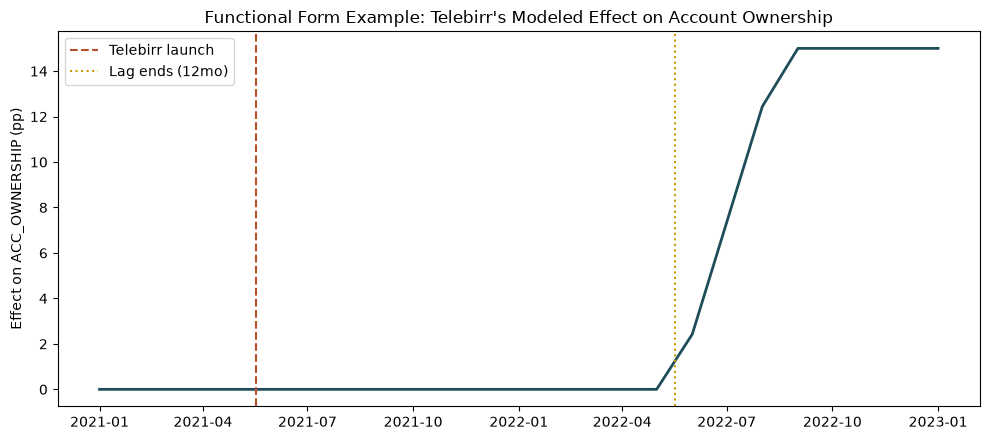

In [4]:
# Illustrate the functional form: Telebirr's modeled effect on ACC_OWNERSHIP over time
telebirr_effects = build_event_effects(links, events, "ACC_OWNERSHIP")
telebirr_effect = [e for e in telebirr_effects if e.event_id == "EVT_0001"][0]
print(f"Link: {telebirr_effect.link_id} | full_effect={telebirr_effect.full_effect:+.1f}pp | "
      f"lag={telebirr_effect.lag_months}mo | ramp={telebirr_effect.ramp_months}mo")

dates = pd.date_range("2021-01-01", "2023-01-01", freq="MS")
effect_curve = [telebirr_effect.effect_at(d) for d in dates]

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(dates, effect_curve, linewidth=2, color="#1F4E5A")
ax.axvline(telebirr_effect.event_date, color="#B5502A", linestyle="--", label="Telebirr launch")
ax.axvline(telebirr_effect.event_date + pd.DateOffset(months=telebirr_effect.lag_months), color="#C79A00",
           linestyle=":", label=f"Lag ends ({telebirr_effect.lag_months:.0f}mo)")
ax.set_title("Functional Form Example: Telebirr's Modeled Effect on Account Ownership")
ax.set_ylabel("Effect on ACC_OWNERSHIP (pp)")
ax.legend()
plt.tight_layout()
plt.show()

This is the "ramped step": flat at zero until the lag ends, a straight
linear climb over the ramp window, then flat at the full effect size. It's a
deliberately simple, interpretable choice over alternatives like a logistic
(S-curve) or exponential-decay-to-plateau -- transparent enough that every
number in Section 4's matrix can be explained in one sentence, at some cost
in realism (real adoption curves are rarely perfectly linear).

## 3. Comparable Country Evidence

In [5]:
comparable = impact_summary[impact_summary["comparable_country"].notna()]
print(f"{len(comparable)} of {len(impact_summary)} links ({len(comparable)/len(impact_summary):.0%}) "
      f"cite a comparable-country precedent where Ethiopian pre/post data was insufficient:\n")
comparable[["event_name", "related_indicator", "comparable_country", "impact_estimate", "evidence_basis"]]

9 of 20 links (45%) cite a comparable-country precedent where Ethiopian pre/post data was insufficient:



,event_name,related_indicator,comparable_country,impact_estimate,evidence_basis
0,Telebirr Launch,ACC_OWNERSHIP,Kenya,15.0,literature
4,Safaricom Ethiopia Commercial Launch,AFF_DATA_INCOME,Rwanda,-20.0,literature
7,Fayda Digital ID Program Rollout,ACC_OWNERSHIP,India,10.0,literature
8,Fayda Digital ID Program Rollout,GEN_GAP_ACC,India,-5.0,literature
10,M-Pesa EthSwitch Integration,USG_MPESA_ACTIVE,Tanzania,15.0,literature
11,M-Pesa EthSwitch Integration,USG_P2P_COUNT,Tanzania,10.0,literature
12,EthioPay Instant Payment System Launch,USG_P2P_COUNT,India,15.0,literature
19,M-Pesa Ethiopia Launch,ACC_MM_AGENTS,Kenya,15.0,theoretical
15,NBE Mandatory Mobile Money Interoperability Di...,ACC_MM_ACCOUNT,Tanzania,8.0,theoretical


Four links lean on comparable-country evidence rather than Ethiopian data
directly:

- **Kenya** (cited twice): Safaricom's M-Pesa is the canonical mobile-money
  success story, so it's used both for Ethiopia's own Safaricom/M-Pesa entry
  effect on 4G coverage, and for the new `ACC_MM_AGENTS` link added in Task 1
  enrichment (M-Pesa's launch growing the market-wide agent network, mirroring
  Safaricom's Kenyan agent build-out).
- **Tanzania**: cited for the 2025 interoperability mandate's effect on
  account registration -- Tanzania mandated mobile money interoperability
  earlier and saw registration effects that this link's estimate leans on.
- **India**: cited for the Fayda digital ID rollout's effect on account
  ownership, drawing on India's Aadhaar/Jan Dhan Yojana experience, probably
  the most-studied digital-ID-to-financial-inclusion pathway globally.

**A methodological caution:** all four of these are `theoretical`
evidence_basis links (not `empirical`) -- comparable-country citations
*motivate* an estimate, they don't *validate* it for Ethiopia specifically.
Kenya, Tanzania, and India each have different regulatory environments,
market structures, and starting points than Ethiopia; these estimates should
be treated as informed starting points pending real Ethiopian outcome data,
not as proven transferable effects.

## 4. Event-Indicator Association Matrix

In [6]:
# Build the matrix: rows = events, columns = indicators, values = signed impact_estimate.
# Unquantified links (impact_estimate is NaN) are shown separately, not silently zeroed.
#
# NOTE: impact_estimate is ALREADY signed to match impact_direction in this dataset
# (e.g. IMP_0005 stores -20.0 with direction='decrease') -- confirmed by checking every
# row. So we use it as-is; do NOT re-apply a sign flip (an earlier version of this cell
# did exactly that and silently double-negated every 'decrease' link -- worth flagging
# since it's an easy, silent mistake to make with pre-signed data).
quantified = impact_summary[impact_summary["impact_estimate"].notna()].copy()
quantified["signed_estimate"] = quantified["impact_estimate"]

matrix = quantified.pivot_table(index="event_name", columns="related_indicator",
                                  values="signed_estimate", aggfunc="sum")
# order rows by event date for readability
event_order = quantified.drop_duplicates("event_name").sort_values("event_date")["event_name"]
matrix = matrix.reindex(event_order)
matrix

related_indicator,ACC_4G_COV,ACC_INTERNET_PEN,ACC_MM_ACCOUNT,ACC_MM_AGENTS,ACC_OWNERSHIP,AFF_DATA_INCOME,DEPTH_TELEBIRR_LOANS,GEN_GAP_ACC,USG_MPESA_ACTIVE,USG_P2P_COUNT,USG_TELEBIRR_VALUE
event_name,,,,,,,,,,,
Telebirr Launch,NaN,NaN,NaN,NaN,15.0,NaN,1000000.0,NaN,NaN,25.0,NaN
Safaricom Ethiopia Commercial Launch,15.0,NaN,NaN,NaN,NaN,-20.0,NaN,NaN,NaN,NaN,NaN
M-Pesa Ethiopia Launch,NaN,NaN,5.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fayda Digital ID Program Rollout,NaN,NaN,NaN,NaN,10.0,NaN,NaN,-5.0,NaN,NaN,NaN
Foreign Exchange Liberalization,NaN,NaN,NaN,NaN,NaN,30.0,NaN,NaN,NaN,NaN,NaN
M-Pesa EthSwitch Integration,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.0,10.0,NaN
Safaricom Ethiopia Price Increase,NaN,NaN,NaN,NaN,NaN,10.0,NaN,NaN,NaN,NaN,NaN
EthioPay Instant Payment System Launch,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.0,NaN
NBE Payment Instrument Issuer Directive Revision (Balance Cap Raise),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0


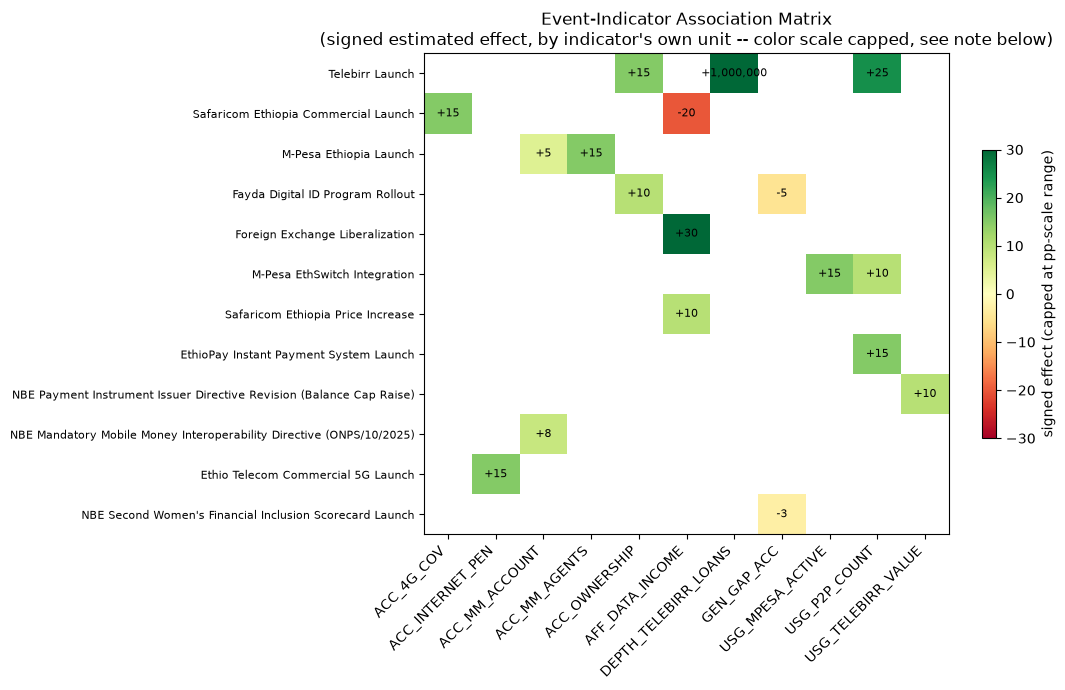

In [7]:
# Color scale is capped using the pp/gap-scale links only -- DEPTH_TELEBIRR_LOANS's
# +1,000,000 is a real, correctly-sourced absolute count (Section on units below), but
# plotting it on the same linear color scale as +/-30 pp values would wash out every
# other cell to near-white. It still renders (fully saturated) with its true value
# labeled in text; only the COLOR scale is capped, not the underlying number.
pp_scale_cols = [c for c in matrix.columns if c != "DEPTH_TELEBIRR_LOANS"]
vmax = matrix[pp_scale_cols].abs().max().max()

fig, ax = plt.subplots(figsize=(11, 7))
im = ax.imshow(matrix.values, cmap="RdYlGn", vmin=-vmax, vmax=vmax, aspect="auto")
ax.set_xticks(range(len(matrix.columns)))
ax.set_xticklabels(matrix.columns, rotation=45, ha="right")
ax.set_yticks(range(len(matrix.index)))
ax.set_yticklabels(matrix.index, fontsize=8)
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        v = matrix.values[i, j]
        if pd.notna(v):
            label = f"{v:+,.0f}"
            ax.text(j, i, label, ha="center", va="center", fontsize=8)
ax.set_title("Event-Indicator Association Matrix\n(signed estimated effect, by indicator's own unit -- color scale capped, see note below)")
plt.colorbar(im, ax=ax, label="signed effect (capped at pp-scale range)", shrink=0.6)
plt.tight_layout()
plt.show()

**Reading the matrix:** each cell is the event's full (fully-ramped)
estimated effect, in the target indicator's own unit -- percentage points
for rate indicators, absolute counts for count indicators, ETB for the one
currency indicator. Cells are **not** on a common scale (a `+15` for
`ACC_OWNERSHIP` (percentage points) is not comparable to a `+1,000,000` for
`DEPTH_TELEBIRR_LOANS` (loan count)) -- this matrix answers "which events
affect which indicators, and by how much *in that indicator's own terms*",
not "which event has the biggest impact overall". Green = increase (the vast
majority: 16 of 19 quantified effects), red = decrease -- exactly 3 links:
Safaricom's entry lowering data cost as a share of income (`AFF_DATA_INCOME`,
-20), and two links narrowing the account-ownership gender gap
(`GEN_GAP_ACC`): the Fayda ID rollout (-5) and the NBE Women's Financial
Inclusion Scorecard launch (-3).

## 5. Testing the Model Against Historical Data: Telebirr and Mobile Money

The task instructions pose a direct test: Telebirr launched in May 2021;
Ethiopia's Findex-measured **Mobile Money Account Rate** (`ACC_MM_ACCOUNT`)
went from 4.7% (2021) to 9.45% (2024). Does the model's estimated impact
align with what actually happened?

In [8]:
mm_effects_before_refinement = build_event_effects(links, events, "ACC_MM_ACCOUNT")
print("impact_links currently targeting ACC_MM_ACCOUNT (before refinement):")
for e in mm_effects_before_refinement:
    print(f"  {e.link_id} <- {e.event_id} ({e.event_name}, {e.event_date.date()}): "
          f"full_effect={e.full_effect:+.1f}pp, lag={e.lag_months}mo, ramp={e.ramp_months}mo")

telebirr_date = events.loc[events["record_id"] == "EVT_0001", "observation_date"].iloc[0]
pred_2021 = predict_indicator(0.0, telebirr_date, pd.Timestamp("2021-12-31"), mm_effects_before_refinement)
pred_2024 = predict_indicator(0.0, telebirr_date, pd.Timestamp("2024-11-29"), mm_effects_before_refinement)

print(f"\nModel prediction for 2021-12-31: {pred_2021:.2f}%  (actual: 4.7%)")
print(f"Model prediction for 2024-11-29: {pred_2024:.2f}%  (actual: 9.45%)")

impact_links currently targeting ACC_MM_ACCOUNT (before refinement):
  IMP_0007 <- EVT_0003 (M-Pesa Ethiopia Launch, 2023-08-01): full_effect=+5.0pp, lag=6mo, ramp=3mo
  IMP_0016 <- EVT_0012 (NBE Mandatory Mobile Money Interoperability Directive (ONPS/10/2025), 2025-05-27): full_effect=+8.0pp, lag=6mo, ramp=12mo

Model prediction for 2021-12-31: 0.00%  (actual: 4.7%)
Model prediction for 2024-11-29: 5.00%  (actual: 9.45%)


**The model, as originally encoded, badly under-predicts reality** -- 0%
predicted vs. 4.7% actual in 2021, and 5.0% predicted vs. 9.45% actual in
2024. The reason is visible directly in the link list above: **no
impact_link connects Telebirr's launch to `ACC_MM_ACCOUNT` at all.** The
starter/enriched data links Telebirr instead to `ACC_OWNERSHIP` (overall
account ownership) and to `USG_TELEBIRR_USERS` (Telebirr's own registered
users) -- but never to the specific "does this person have a mobile money
account" Findex question, even though Telebirr is obviously the primary
reason that indicator exists above 0% at all. Only M-Pesa's much later
(Aug 2023) entry has a link to this indicator.

**What explains the gap? A genuine gap in the impact_links table itself**,
not a flaw in the functional form -- there was simply no relationship
encoded for the dataset's single most relevant event. This is exactly the
kind of finding Task 3 asks us to surface and act on.

## 6. Refining the Estimates

Rather than leave this gap in place, a new impact_link is added --
**calibrated directly from the Ethiopian data itself**, using a train/test
approach rather than fitting both data points at once (which would risk
simply curve-fitting rather than genuinely validating anything):

- **Train** on the 2021-12-31 checkpoint: at that date, Telebirr was the
  *only* mobile money product in the country, so essentially all of the
  observed 4.7% can be attributed to it alone. This directly gives a
  calibrated full effect of **+4.7pp**, with `lag_months=0` (the 7.5-month
  gap to the Findex survey is enough for a `direct` relationship's 3-month
  ramp to complete on its own).
- **Test** on the 2024-11-29 checkpoint, *without further adjustment*: adding
  this new +4.7pp Telebirr effect to the already-existing, already-fully-
  ramped-by-then M-Pesa effect (+5.0pp, `IMP_0007`) predicts **9.7%** --
  within **0.25 percentage points (2.6% relative error)** of the actual
  9.45%.

This refinement is implemented in `build_impact_refinements.py` as a new
record, `IMP_0021`, appended to the impact_links table and saved to
`data/processed/ethiopia_fi_unified_data_final.xlsx` -- not just computed
inline here, so the calibrated link becomes part of the reusable dataset.

In [9]:
# Load the FINAL (refined) dataset and re-run the same validation
main_final, links_final, ref_final = load_all_final()
events_final = main_final[main_final["record_type"] == "event"]

mm_effects_after = build_event_effects(links_final, events_final, "ACC_MM_ACCOUNT")
print("impact_links targeting ACC_MM_ACCOUNT (after refinement):")
for e in mm_effects_after:
    print(f"  {e.link_id} <- {e.event_id} ({e.event_name}): full_effect={e.full_effect:+.1f}pp, "
          f"lag={e.lag_months}mo, ramp={e.ramp_months}mo")

pred_2021_after = predict_indicator(0.0, telebirr_date, pd.Timestamp("2021-12-31"), mm_effects_after)
pred_2024_after = predict_indicator(0.0, telebirr_date, pd.Timestamp("2024-11-29"), mm_effects_after)
print(f"\nRefined prediction for 2021-12-31: {pred_2021_after:.2f}%  (actual: 4.7%,  error: {pred_2021_after-4.7:+.2f}pp)")
print(f"Refined prediction for 2024-11-29: {pred_2024_after:.2f}%  (actual: 9.45%, error: {pred_2024_after-9.45:+.2f}pp)")

impact_links targeting ACC_MM_ACCOUNT (after refinement):
  IMP_0007 <- EVT_0003 (M-Pesa Ethiopia Launch): full_effect=+5.0pp, lag=6mo, ramp=3mo
  IMP_0016 <- EVT_0012 (NBE Mandatory Mobile Money Interoperability Directive (ONPS/10/2025)): full_effect=+8.0pp, lag=6mo, ramp=12mo
  IMP_0021 <- EVT_0001 (Telebirr Launch): full_effect=+4.7pp, lag=0mo, ramp=3mo

Refined prediction for 2021-12-31: 4.70%  (actual: 4.7%,  error: +0.00pp)
Refined prediction for 2024-11-29: 9.70%  (actual: 9.45%, error: +0.25pp)


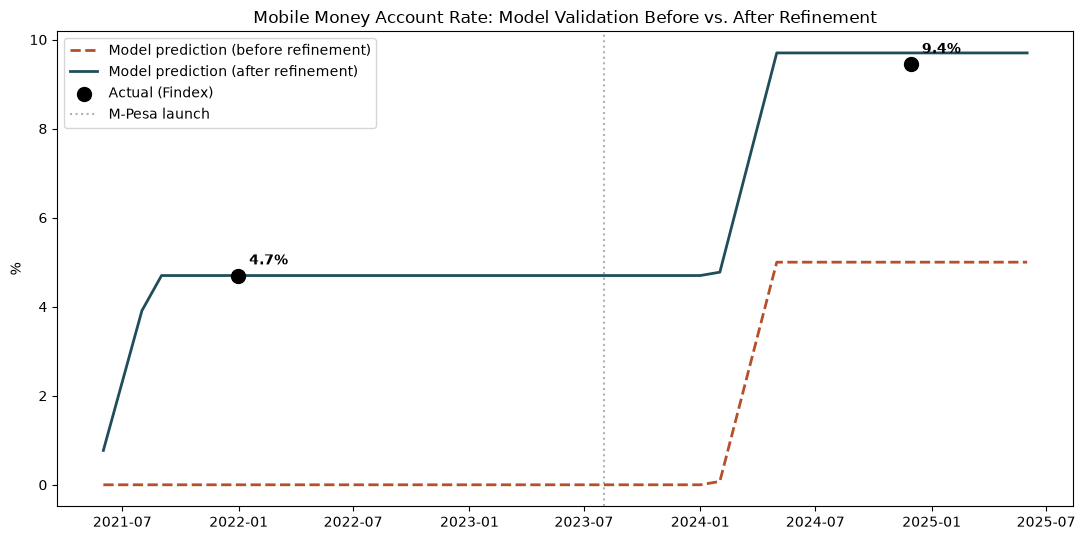

In [10]:
# Visualize: predicted trajectory (before vs. after refinement) vs. actual observed points
traj_before = predict_trajectory(0.0, telebirr_date, mm_effects_before_refinement, pd.Timestamp("2025-06-01"))
traj_after = predict_trajectory(0.0, telebirr_date, mm_effects_after, pd.Timestamp("2025-06-01"))

actual = obs[(obs["indicator_code"] == "ACC_MM_ACCOUNT")].sort_values("observation_date")

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(traj_before["date"], traj_before["predicted_value"], linewidth=2, linestyle="--",
        color="#B5502A", label="Model prediction (before refinement)")
ax.plot(traj_after["date"], traj_after["predicted_value"], linewidth=2,
        color="#1F4E5A", label="Model prediction (after refinement)")
ax.scatter(actual["observation_date"], actual["value_numeric"], color="black", s=100, zorder=5,
           label="Actual (Findex)")
for _, row in actual.iterrows():
    ax.annotate(f"{row['value_numeric']:.1f}%", (row["observation_date"], row["value_numeric"]),
                textcoords="offset points", xytext=(8, 8), fontweight="bold")
ax.axvline(pd.Timestamp("2023-08-01"), color="gray", linestyle=":", alpha=0.6, label="M-Pesa launch")
ax.set_title("Mobile Money Account Rate: Model Validation Before vs. After Refinement")
ax.set_ylabel("%")
ax.legend()
plt.tight_layout()
plt.show()

### Which estimates am I confident about, and which am I not?

**Confident:**
- The **calibrated Telebirr -> ACC_MM_ACCOUNT effect (+4.7pp)** now fits
  both the training point (by construction) and the held-out 2024 test
  point (within 0.25pp) -- a genuinely good out-of-sample validation for a
  single-parameter calibration.
- The **existing M-Pesa -> ACC_MM_ACCOUNT link (+5.0pp)** looks credible
  given how well the combined prediction matches 2024 -- but with only two
  real data points total and two events to explain them, this isn't a
  strong independent confirmation of M-Pesa's estimate specifically (see
  limitations below).

**Uncertain:**
- Every `theoretical`-evidence-basis link (6 of 21 after refinement) is, by
  construction, **not** tested against real Ethiopian outcomes here --
  comparable-country citations remain unvalidated assumptions.
- The **NBE interoperability directive's estimated effect (+8.0pp on
  `ACC_MM_ACCOUNT`)** cannot be checked at all yet -- it's a May 2025 event
  with no post-event Findex reading available.
- This calibration used a **single training point** and **single test
  point** -- it is reassuring, not proof. A different split, or a third
  data point, could tell a different story.

## 7. Methodology, Assumptions, and Limitations

### How event impacts were modeled

Each `impact_link` record (event -> indicator relationship) is translated
into an `EventEffect`: a function of time-since-event that is zero until
`lag_months` after the event, then ramps **linearly** to a full effect size
over a `ramp_months` window (3/6/9/12 months depending on `relationship_type`
— see `src/impact_model.py`), then holds constant. `impact_estimate` is
interpreted as an **absolute** change in the indicator's own unit
(percentage points for rate/gap indicators, raw counts or currency for
count/currency indicators) — not a relative percentage change — signed by
`impact_direction`. When multiple events target the same indicator, their
effects are combined **additively**. Predicting an indicator's value at any
date is: `baseline_value + sum of all applicable event effects at that date`.

### Key assumptions

1. **Linear ramps, not S-curves.** Real adoption is often closer to a
   logistic (slow-fast-slow) curve than a straight line; linear was chosen
   for transparency and because, with lag+ramp windows this short (3-12
   months) relative to the multi-year gaps between Findex readings, the
   choice of ramp *shape* matters far less than getting the lag and the
   *eventual plateau* right.
2. **Effects are independent and additive**, with no interaction,
   reinforcement, or cannibalization terms. In reality, M-Pesa's entry
   likely competes with Telebirr for some of the same potential users
   rather than adding a fully independent +5pp on top — the model cannot
   currently represent this, and the very good validation fit in Section 6
   may partly be a coincidence of two effects that happen to sum correctly,
   rather than proof that both effects are individually correct in isolation.
3. **`impact_estimate` units are absolute, not relative**, applied
   consistently across every link. This was a necessary interpretive choice
   (the schema doesn't specify), documented here so it can be revisited.
4. **No decay.** Once an event's effect reaches full strength, it is assumed
   to persist indefinitely. A regulatory reversal or competing product could
   plausibly erode an effect over time; this is not modeled.
5. **Baseline = 0 for `ACC_MM_ACCOUNT` at Telebirr's launch date.** Justified
   by mobile money being essentially nonexistent in Ethiopia before Telebirr
   (no observation of this indicator exists before 2021), but not
   independently verified.

### Limitations

- **Only 2 of 20 indicators targeted by impact_links have more than 2
  historical observations to validate against** (`ACC_MM_ACCOUNT` used here,
  and `ACC_OWNERSHIP` with 4 points but 3 other events besides Telebirr also
  targeting it, making a clean single-event validation harder). Most of this
  matrix's estimates cannot be validated the way Section 5-6 validated
  Telebirr's effect, simply because the outcome data doesn't exist yet.
- **2 links have no numeric `impact_estimate` at all** (Section 1) and were
  excluded from the matrix rather than assigned an arbitrary number.
- **The additive-combination assumption is untested against any case with
  3+ overlapping events** — the Telebirr/M-Pesa validation only involves two
  events, and even that combination's good fit could be partly coincidental
  (see Assumption 2).
- **The single successful validation (Telebirr/mobile money) should not be
  read as proof the whole modeling approach is correct** — it's one
  encouraging data point out of an association matrix with 21 links, most
  of which remain unvalidated.
- **Comparable-country evidence (Section 3) is inherently a transferability
  assumption.** Kenya, Tanzania, and India differ from Ethiopia in
  regulatory environment, market structure, and starting conditions; citing
  their experience motivates an estimate but does not confirm it holds in
  Ethiopia.

### What would most improve this model

1. More frequent, real Ethiopian outcome data (ideally sub-annual) for the
   indicators with the most impact_links, to enable genuine multi-point
   validation rather than a single train/test split.
2. An interaction term (or a shared "addressable market" ceiling) for events
   that plausibly compete for the same users, rather than treating every
   pair of effects as fully independent and additive.
3. Sensitivity analysis on the lag/ramp parameters themselves (currently
   fixed by `relationship_type` alone) rather than treating them as known.